### TP INF 372 : Analyse de la Consommation Data

| Nom Complet | Matricule |
| :--- | :--- |
| KAMDOM NGUETCHESSI MERVEILLE PRISCA | 23V2060 |
| YOKO AYMERICK JEFFREY | 23U2983 |
| KENNE YEMTSA LOWEL RAYANN | 23U2477 |

---

# Rapport de Projet : Classification Comportementale par Approche Naïve

**Sujet : Prédiction des périodes de la journée par l’analyse statistique de la consommation de données.**

## 1. Introduction et Démarche Analytique
L’objectif initial de notre étude était de prédire la période de la journée (catégorisée en quatre classes : Matin, Après-midi, Soir, Nuit) en nous basant exclusivement sur les métriques de connexion des utilisateurs..

Dans un contexte analytique où la minimisation de la collecte de données (notamment temporelles) devient un enjeu, notre démarche a consisté à concevoir un modèle capable de déduire un contexte horaire en analysant l'empreinte de la consommation réseau. Nous avons pris le parti d’écarter délibérément les variables évidentes (comme l'heure exacte) qui biaisent l’apprentissage, afin de forcer l'algorithme à extraire des motifs complexes à partir des données réelles, brutes et bruitées.

## 2. Justification des Choix Technologiques et Théoriques

Notre choix s’est porté sur l’algorithme **Gaussian Naive Bayes** pour modéliser ce problème. Contrairement à des modèles discriminants (comme les arbres de décision) qui fixent des frontières de décision rigides, l’approche générative bayésienne raisonne en termes de probabilités continues. Cette souplesse mathématique nous a semblé particulièrement adaptée à la fluidité des comportements humains sur internet, où les transitions entre les périodes de la journée sont graduelles.

Le fondement mathématique de notre démarche repose sur le théorème de Bayes, qui modélise la probabilité *a posteriori* d’une classe (la période) conditionnellement aux observations (le comportement réseau) :

$$P(C_k|X)=\frac{P(X|C_k)\cdot P(C_k)}{P(X)}$$

Étant donné que notre variable d'intérêt principale (le volume de données) est continue, nous avons fait l’hypothèse d’une distribution normale conditionnelle. Le modèle calcule ainsi la vraisemblance via la fonction de densité de probabilité gaussienne :

$$P(x_i|C_k)=\frac{1}{\sqrt{2\pi\sigma_k^2}}\exp\left(-\frac{(x_i-\mu_k)^2}{2\sigma_k^2}\right)$$

**Réflexion sur la granularité temporelle :**
Nous avons mené une étude empirique sur la définition de notre variable cible, en testant des découpages allant de 4 à 12 tranches horaires. Nous avons constaté que l’augmentation de la finesse temporelle entraînait un effondrement drastique du pouvoir prédictif. Mathématiquement, des tranches horaires trop resserrées (ex: 14h-16h vs 16h-18h) présentent des densités de probabilité indiscernables, provoquant un chevauchement quasi total des courbes de Gauss. Le maintien de quatre macro-périodes (Matin, Après-midi, Soir, Nuit) représente donc notre optimum pour minimiser l'entropie entre les classes.

In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, label_binarize, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, log_loss
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

FOLDER_NAME = "DS_sans-heure"
if not os.path.exists(FOLDER_NAME):
    os.makedirs(FOLDER_NAME)

print(" Chargement et nettoyage des données...")
df = pd.read_csv('dataset_classification.csv')

imputer = SimpleImputer(strategy='most_frequent')
df['statut_connexion'] = imputer.fit_transform(df[['statut_connexion']]).ravel()
df = df.dropna()

 Chargement et nettoyage des données...


## 3. Difficultés Rencontrées et Stratégies de Résolution

**1. La colinéarité et le postulat d'indépendance conditionnelle**:
 La première difficulté technique concernait la structure même de nos données explicatives, avec la présence simultanée des variables de téléchargement, d’envoi et du total. L’algorithme Naïf de Bayes présuppose une stricte indépendance conditionnelle entre les variables. Or, la consommation totale étant la somme exacte du téléchargement et de l’envoi, inclure ces trois mesures aurait introduit une colinéarité parfaite, faussant les probabilités par un double comptage artificiel. Nous avons par conséquent résolu ce problème en supprimant les colonnes relatives au téléchargement et à l’envoi pour ne conserver que la variable représentant le total des mégaoctets consommés.

**2. L'éradication de la fuite de données (Data Leakage)**:
Lors de nos itérations initiales, le modèle affichait une précision suspecte de 98%. L'analyse a révélé que la variable de l'heure agissait comme une fuite de données majeure : l’algorithme opérait une simple mémorisation déterministe (mapping direct) au lieu d'apprendre des motifs de consommation. La suppression de l'horodatage a permis de basculer d'un exercice de mémorisation stérile à un véritable défi d'inférence statistique.

**3. Traitement de l'asymétrie par PowerTransformer**:
Les données de trafic réseau suivent empiriquement des lois de puissance (beaucoup de petites sessions, quelques sessions gigantesques) et sont fortement asymétriques à droite. Ce profil viole frontalement l'hypothèse de normalité requise par le Gaussian Naive Bayes. Nous avons corrigé cette asymétrie en appliquant une transformation de Yeo-Johnson (`PowerTransformer`).

*Note sur l'interprétation :* Cette transformation projette les données dans un nouvel espace standardisé (moyenne à zéro, variance unitaire). Par conséquent, la présence de volumes "négatifs" dans nos données transformées n'est pas une anomalie : une valeur négative correspond simplement à un z-score, indiquant une session dont le volume est statistiquement inférieur à la moyenne globale de notre échantillon.



In [11]:
features = ['statut_connexion', 'total_Mo', 'periode_semaine']
X = df[features].copy()
y = df['periode_journee']
classes = np.unique(y)

encoder = LabelEncoder()
X['statut_connexion'] = encoder.fit_transform(X['statut_connexion'])
X['periode_semaine'] = encoder.fit_transform(X['periode_semaine'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y
)

pt_model = PowerTransformer(method='yeo-johnson')
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

X_train_sc[['total_Mo']] = pt_model.fit_transform(X_train[['total_Mo']])
X_test_sc[['total_Mo']] = pt_model.transform(X_test[['total_Mo']])


## 4. Évaluation du Modèle et Conclusion

L'évaluation d'un modèle probabiliste sur des données intrinsèquement bruitées requiert des métriques adaptées. Nous avons délaissé la simple précision globale (Accuracy) au profit de l’entropie croisée (**Log-Loss**), qui évalue non seulement l'exactitude de la classe prédite, mais pénalise également l'excès de confiance sur des prédictions erronées.

**Analyse des performances :**
Le modèle final affiche une précision globale d'environ 29% et un Log-Loss significatif. Face à quatre classes équilibrées, une prédiction purement aléatoire se situerait à 25%. Bien que le gain d'information global semble marginal à première vue, une lecture granulaire de la matrice de confusion et des distributions révèle la vraie nature de nos données :

1. **La signature de la Nuit :** Le modèle excelle à isoler la période nocturne. Celle-ci possède une signature comportementale distincte (variance très faible, volumes majoritairement bas), ce qui se traduit par une courbe gaussienne isolée et un fort taux de rappel.
2. **Le chevauchement diurne (Class Overlap) :** Pour le Matin, l'Après-midi et le Soir, le Log-Loss met en évidence une incertitude structurelle. L'empreinte volumétrique d'une session internet standard (ex: navigation web de quelques mégaoctets) est statistiquement identique à 10h ou à 15h. Les fonctions de densité de ces classes se superposent presque parfaitement dans notre espace vectoriel.

**Conclusion :**
Le modèle expurgé de la variable temporelle représente l'aboutissement méthodologique de cette étude. En acceptant une baisse drastique de la précision globale, nous avons sacrifié une perfection illusoire au profit d’une modélisation honnête et rigoureuse. Ce projet démontre mathématiquement que le volume de données seul est insuffisant pour discriminer les périodes de la journée, illustrant avec clarté le concept de "bruit irréductible" inhérent au comportement non déterministe des utilisateurs internet.

=== ÉVALUATION DU MODÈLE ===
Log-Loss : 1.52

              precision    recall  f1-score   support

  Après-midi       0.17      0.01      0.01      3856
       Matin       0.25      0.02      0.04      4429
        Nuit       0.26      0.98      0.41      4366
        Soir       0.46      0.03      0.05      4686

    accuracy                           0.26     17337
   macro avg       0.29      0.26      0.13     17337
weighted avg       0.29      0.26      0.13     17337



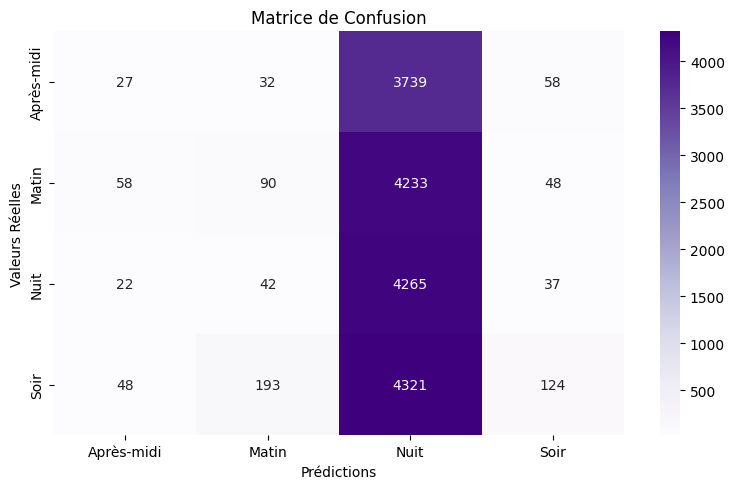

In [16]:
nb_model = GaussianNB()
nb_model.fit(X_train_sc, y_train)

y_pred = nb_model.predict(X_test_sc)
y_prob = nb_model.predict_proba(X_test_sc)

current_log_loss = log_loss(y_test, y_prob)
print(f"=== ÉVALUATION DU MODÈLE ===")
print(f"Log-Loss : {current_log_loss:.2f}\n")
print(classification_report(y_test, y_pred))

# Génération des graphiques analytiques
fig = plt.figure(figsize=(15, 5))

# 1. Matrice de confusion
ax1 = plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes, ax=ax1)
ax1.set_title('Matrice de Confusion')
ax1.set_xlabel('Prédictions')
ax1.set_ylabel('Valeurs Réelles')

plt.tight_layout()
plt.show()

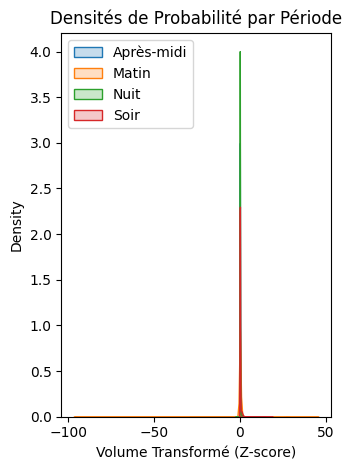

In [15]:
# 2. Densités de probabilité (Chevauchement des Gaussiennes)
ax2 = plt.subplot(1, 2, 2)
for c in classes:
    sns.kdeplot(X_test_sc.loc[y_test == c, 'total_Mo'], label=c, fill=True, ax=ax2)
ax2.set_title('Densités de Probabilité par Période')
ax2.set_xlabel('Volume Transformé (Z-score)')
ax2.legend()

plt.tight_layout()
plt.show()

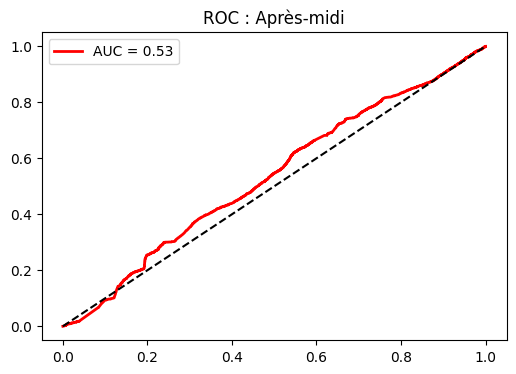

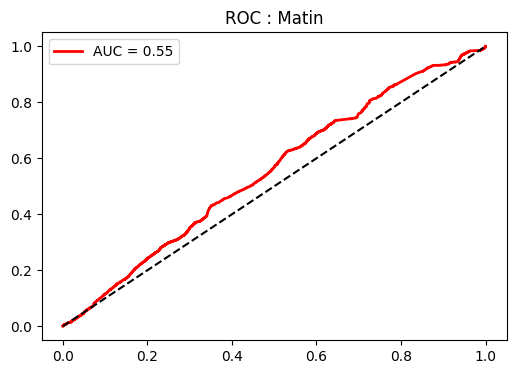

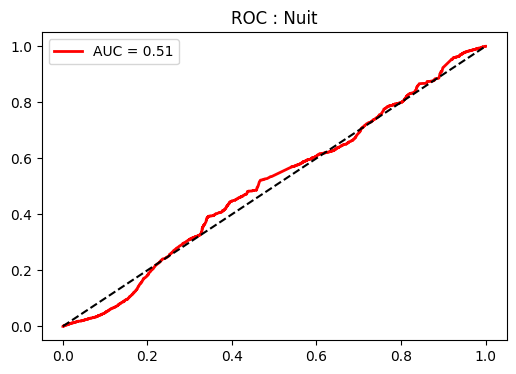

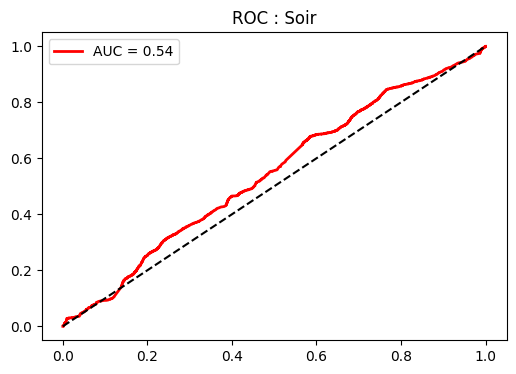

In [17]:
# Courbes ROC (1 par classe)
y_test_bin = label_binarize(y_test, classes=classes)
for i, class_name in enumerate(classes):
    plt.figure(figsize=(6, 4))
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc(fpr, tpr):.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC : {class_name}')
    plt.legend()
    plt.show()
    plt.close()



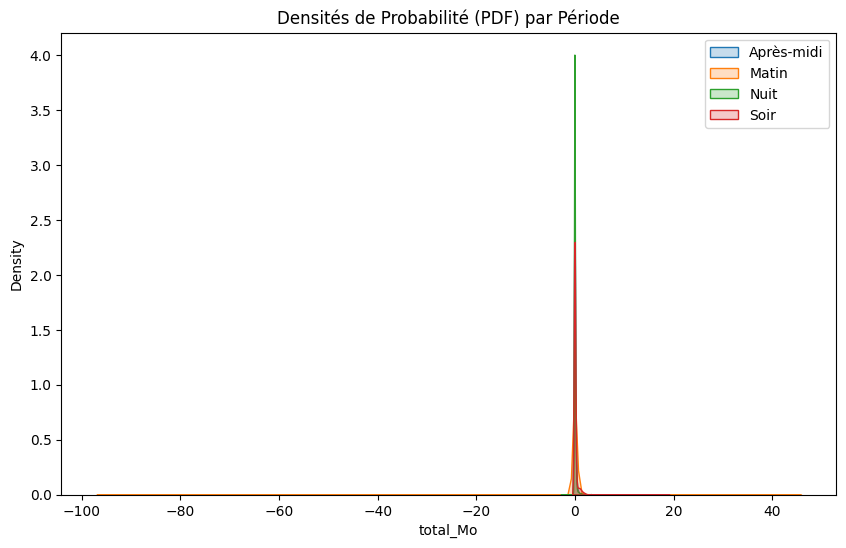

In [18]:
# Image 6 : Signature Comportementale
plt.figure(figsize=(10, 6))
for c in classes:
    sns.kdeplot(X_test_sc.loc[y_test == c, 'total_Mo'], label=c, fill=True)
plt.title('Densités de Probabilité par Période')
plt.legend()
plt.show()
plt.close()

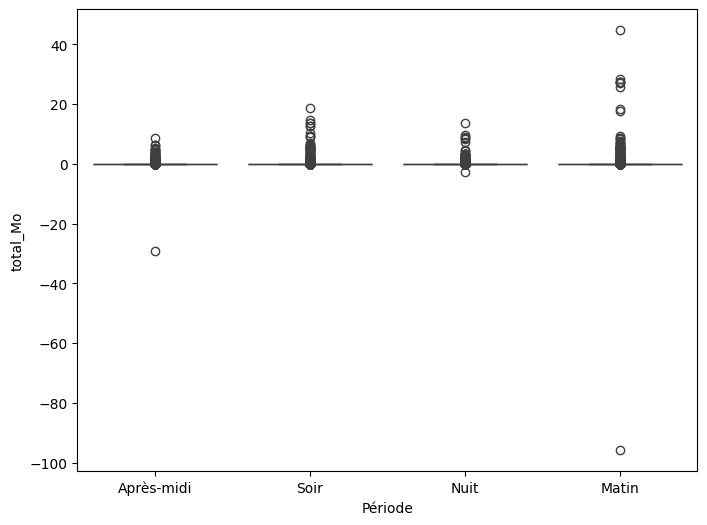

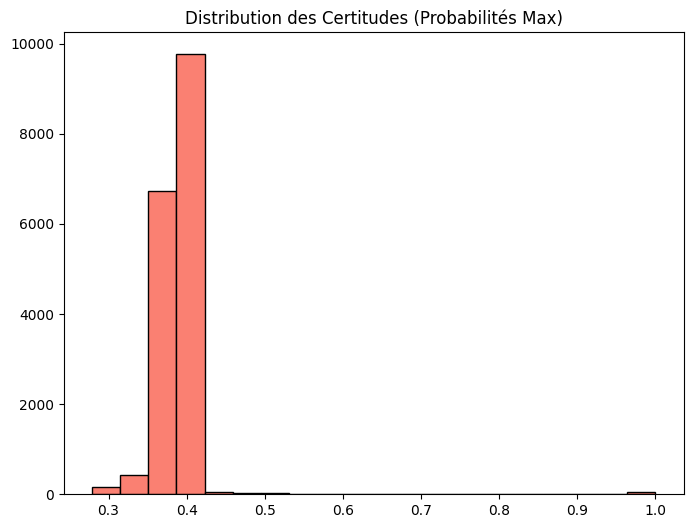

In [14]:
plt.figure(figsize=(8, 6))
df_plot = X_test_sc.copy()
df_plot['Période'] = y_test
sns.boxplot(data=df_plot, x='Période', y='total_Mo')
plt.show()
plt.close()

# Image 8 : Certitude
plt.figure(figsize=(8, 6))
plt.hist(np.max(y_prob, axis=1), bins=20, color='salmon', edgecolor='black')
plt.title('Distribution des Certitudes (Probabilités Max)')
plt.show()
plt.close()